In [1]:
import os, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, precision_score, recall_score, f1_score,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
os.makedirs("images", exist_ok=True)      # plots are saved here (use them in the README)
os.makedirs("artifacts", exist_ok=True)   # trained model + preprocessor are saved here

SEED = 42

def set_seed(seed=SEED):
    """Fix all random seeds so results are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

In [2]:
df = pd.read_csv("ai4i2020.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
df.info()

Duplicate rows: 0
Missing values: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  

Machine failure
0    9661
1     339
Name: count, dtype: int64
Failure rate: 3.39%


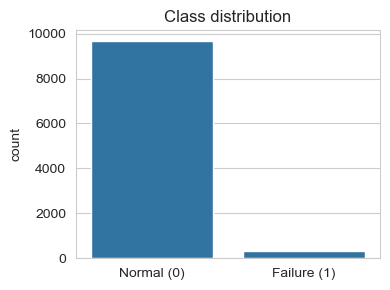

In [4]:
counts = df["Machine failure"].value_counts()
print(counts)
print(f"Failure rate: {df['Machine failure'].mean() * 100:.2f}%")

plt.figure(figsize=(4, 3))
ax = sns.countplot(x="Machine failure", data=df)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Normal (0)", "Failure (1)"])
ax.set_xlabel("")
ax.set_title("Class distribution")
plt.tight_layout()
plt.savefig("images/class_distribution.png", dpi=150)
plt.show()

Type
H    2.09
L    3.92
M    2.77
Name: Machine failure, dtype: float64


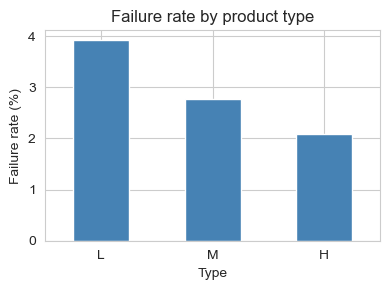

In [5]:
type_rate = df.groupby("Type")["Machine failure"].mean().mul(100)
print(type_rate.round(2))

ax = type_rate.reindex(["L", "M", "H"]).plot(kind="bar", figsize=(4, 3), rot=0, color="steelblue")
ax.set_ylabel("Failure rate (%)")
ax.set_title("Failure rate by product type")
plt.tight_layout()
plt.savefig("images/failure_rate_by_type.png", dpi=150)
plt.show()

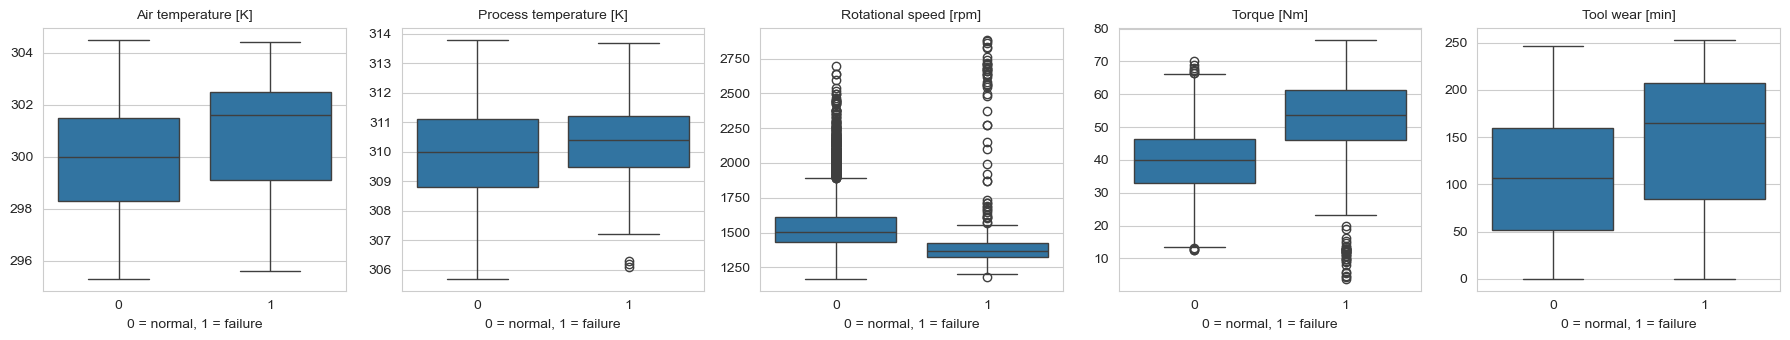

In [6]:
raw_features = ["Air temperature [K]", "Process temperature [K]",
                "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, col in zip(axes, raw_features):
    sns.boxplot(x="Machine failure", y=col, data=df, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("0 = normal, 1 = failure")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig("images/feature_distributions.png", dpi=150)
plt.show()

In [7]:
df["Thermal_Strain"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Power"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]

leak_cols = ["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"]
df_model = df.drop(columns=leak_cols)
df_model.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Thermal_Strain,Power
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0


Machine failure            1.000
Torque [Nm]                0.191
Power                      0.176
Tool wear [min]            0.105
Air temperature [K]        0.083
Process temperature [K]    0.036
Rotational speed [rpm]    -0.044
Thermal_Strain            -0.112
Name: Machine failure, dtype: float64


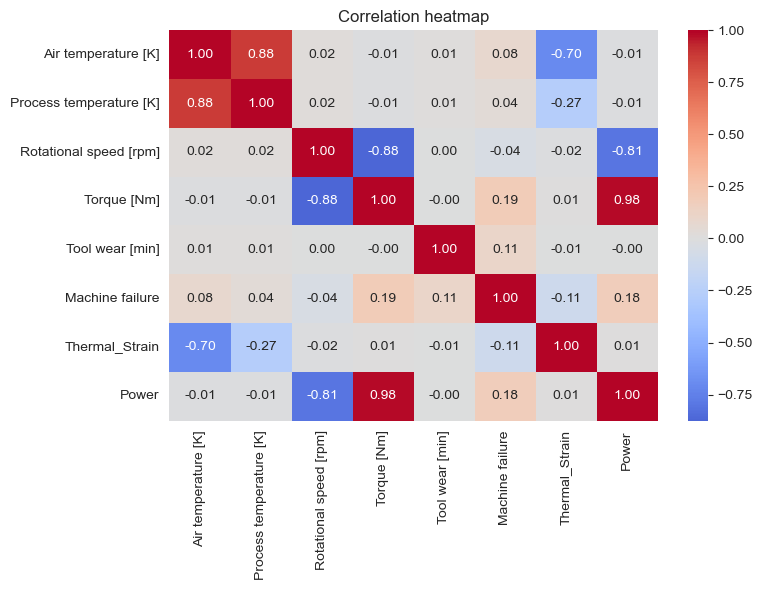

In [8]:
numeric_df = df_model.drop(columns=["Type"])
print(numeric_df.corr()["Machine failure"].sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=150)
plt.show()

In [9]:
X = df_model.drop(columns="Machine failure")
y = df_model["Machine failure"]

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=SEED, stratify=y_dev)

for name, part in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<11} samples: {len(part):>5}   failures: {int(part.sum()):>3} ({part.mean() * 100:.2f}%)")

Train       samples:  6000   failures: 203 (3.38%)
Validation  samples:  2000   failures:  68 (3.40%)
Test        samples:  2000   failures:  68 (3.40%)


In [10]:
ALL_NUM = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
           "Torque [Nm]", "Tool wear [min]", "Thermal_Strain", "Power"]
BASE_NUM = raw_features   # same list without the engineered features (used in the ablation study)

def make_preprocessor(num_cols):
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Type"]),
    ])

preprocessor = make_preprocessor(ALL_NUM)
X_train_s = preprocessor.fit_transform(X_train)
X_val_s = preprocessor.transform(X_val)
X_test_s = preprocessor.transform(X_test)

INPUT_DIM = X_train_s.shape[1]
print("Input features:", INPUT_DIM)
print(list(preprocessor.get_feature_names_out()))

Input features: 10
['num__Air temperature [K]', 'num__Process temperature [K]', 'num__Rotational speed [rpm]', 'num__Torque [Nm]', 'num__Tool wear [min]', 'num__Thermal_Strain', 'num__Power', 'cat__Type_H', 'cat__Type_L', 'cat__Type_M']


In [11]:
baselines = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                            class_weight="balanced", random_state=SEED, n_jobs=-1),
}

try:
    from xgboost import XGBClassifier
    scale_pos = float((y_train == 0).sum() / (y_train == 1).sum())
    baselines["XGBoost"] = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                         scale_pos_weight=scale_pos, eval_metric="logloss",
                                         random_state=SEED)
except ImportError:
    print("xgboost is not installed, skipping it (pip install xgboost to include it).")

results = {}   # model name -> validation and test probabilities
for name, clf in baselines.items():
    clf.fit(X_train_s, y_train)
    results[name] = {
        "val_probs": clf.predict_proba(X_val_s)[:, 1],
        "test_probs": clf.predict_proba(X_test_s)[:, 1],
    }
    print(f"{name:<20} validation PR-AUC = {average_precision_score(y_val, results[name]['val_probs']):.3f}")

xgboost is not installed, skipping it (pip install xgboost to include it).
Logistic Regression  validation PR-AUC = 0.451
Random Forest        validation PR-AUC = 0.832


In [12]:
class Ann(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.model(x)


def predict_proba_ann(model, X):
    """Return failure probabilities (numpy array) for a preprocessed feature matrix."""
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(np.asarray(X), dtype=torch.float32))
        return torch.sigmoid(logits).numpy().ravel()


def train_ann(X_tr, y_tr, X_va, y_va, seed=SEED, max_epochs=100, patience=10,
              lr=1e-3, batch_size=32, verbose=True):
    """Train the ANN with weighted loss and early stopping. Returns (model, history, pos_weight)."""
    set_seed(seed)
    y_tr_np, y_va_np = np.asarray(y_tr), np.asarray(y_va)

    X_tr_t = torch.tensor(np.asarray(X_tr), dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_np, dtype=torch.float32).view(-1, 1)
    X_va_t = torch.tensor(np.asarray(X_va), dtype=torch.float32)
    y_va_t = torch.tensor(y_va_np, dtype=torch.float32).view(-1, 1)

    # Failures are rare, so give them a higher weight in the loss
    pos_weight = torch.tensor([(y_tr_np == 0).sum() / (y_tr_np == 1).sum()], dtype=torch.float32)

    model = Ann(X_tr_t.shape[1])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)

    history = {"train_loss": [], "val_loss": []}
    best_val, best_state, wait = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(X_tr_t)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_va_t), y_va_t).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-4:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best validation loss {best_val:.4f})")
                break

    model.load_state_dict(best_state)
    return model, history, pos_weight.item()

Early stopping at epoch 51 (best validation loss 0.4727)
pos_weight (calculated from training data): 28.56


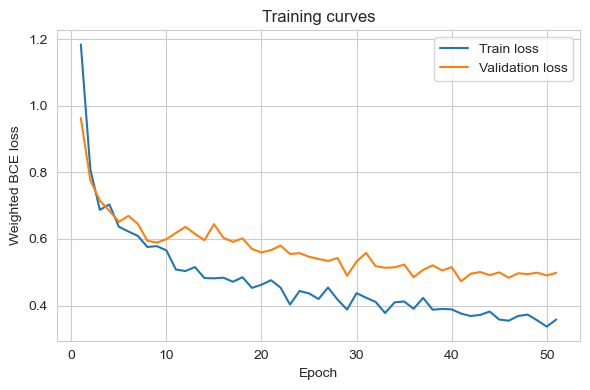

In [13]:
ann, history, pos_weight_used = train_ann(X_train_s, y_train, X_val_s, y_val)
print(f"pos_weight (calculated from training data): {pos_weight_used:.2f}")

plt.figure(figsize=(6, 4))
epochs = range(1, len(history["train_loss"]) + 1)
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Weighted BCE loss")
plt.title("Training curves")
plt.legend()
plt.tight_layout()
plt.savefig("images/training_curves.png", dpi=150)
plt.show()

results["ANN"] = {
    "val_probs": predict_proba_ann(ann, X_val_s),
    "test_probs": predict_proba_ann(ann, X_test_s),
}

In [14]:
def best_threshold(y_true, probs, beta=2.0):
    """Threshold that maximizes the F-beta score on the given data."""
    prec, rec, thr = precision_recall_curve(y_true, probs)
    prec, rec = prec[:-1], rec[:-1]            # align with thresholds
    fbeta = (1 + beta**2) * prec * rec / np.maximum(beta**2 * prec + rec, 1e-12)
    i = int(np.argmax(fbeta))
    return float(thr[i]), float(fbeta[i])

thr_tuned, f2_val = best_threshold(y_val, results["ANN"]["val_probs"])
print(f"Tuned threshold: {thr_tuned:.3f}  (validation F2 = {f2_val:.3f})")
print("Note: the validation set has few failures, so this threshold is an estimate, not an exact value.")

Tuned threshold: 0.874  (validation F2 = 0.701)
Note: the validation set has few failures, so this threshold is an estimate, not an exact value.


,Val PR-AUC,Test PR-AUC,Test ROC-AUC
Model,,,
Logistic Regression,0.451,0.471,0.930
Random Forest,0.832,0.853,0.958
ANN,0.708,0.701,0.970


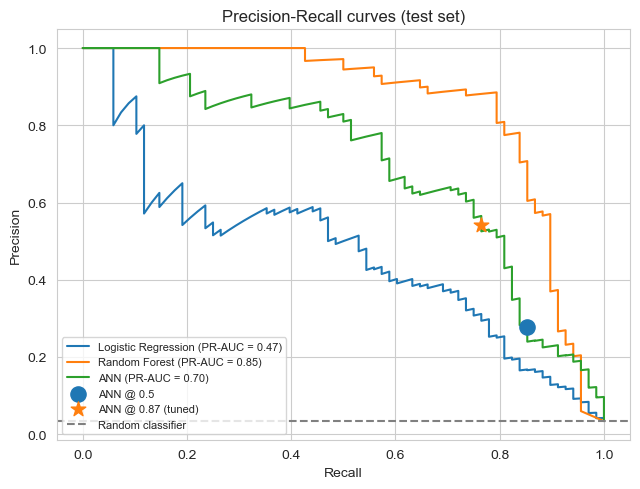

In [15]:
rows = []
for name, r in results.items():
    rows.append({
        "Model": name,
        "Val PR-AUC": average_precision_score(y_val, r["val_probs"]),
        "Test PR-AUC": average_precision_score(y_test, r["test_probs"]),
        "Test ROC-AUC": roc_auc_score(y_test, r["test_probs"]),
    })
comparison = pd.DataFrame(rows).set_index("Model").round(3)
display(comparison)

ann_test_probs = results["ANN"]["test_probs"]

plt.figure(figsize=(6.5, 5))
for name, r in results.items():
    p, rc, _ = precision_recall_curve(y_test, r["test_probs"])
    ap = average_precision_score(y_test, r["test_probs"])
    plt.plot(rc, p, label=f"{name} (PR-AUC = {ap:.2f})")
for label, thr, marker in [("ANN @ 0.5", 0.5, "o"), (f"ANN @ {thr_tuned:.2f} (tuned)", thr_tuned, "*")]:
    preds = (ann_test_probs >= thr).astype(int)
    plt.scatter(recall_score(y_test, preds), precision_score(y_test, preds, zero_division=0),
                s=120, marker=marker, zorder=5, label=label)
plt.axhline(y_test.mean(), ls="--", c="gray", label="Random classifier")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (test set)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("images/pr_curves.png", dpi=150)
plt.show()

===== ANN, threshold: Default 0.5 =====
              precision    recall  f1-score   support

      Normal      0.994     0.922     0.957      1932
     Failure      0.278     0.853     0.419        68

    accuracy                          0.919      2000
   macro avg      0.636     0.887     0.688      2000
weighted avg      0.970     0.919     0.938      2000

===== ANN, threshold: Tuned 0.87 =====
              precision    recall  f1-score   support

      Normal      0.992     0.977     0.984      1932
     Failure      0.542     0.765     0.634        68

    accuracy                          0.970      2000
   macro avg      0.767     0.871     0.809      2000
weighted avg      0.976     0.970     0.972      2000



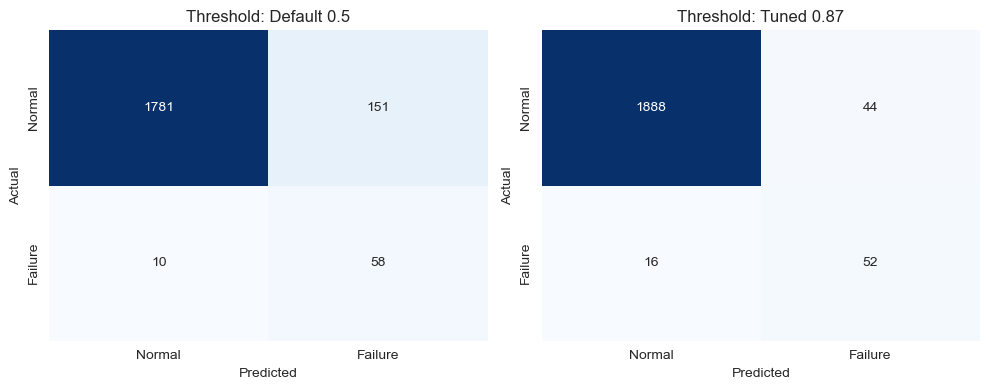

,Precision,Recall,F1,Failures caught,Missed failures,False alarms
Setup,,,,,,
"ANN, threshold Default 0.5",0.278,0.853,0.419,58,10,151
"ANN, threshold Tuned 0.87",0.542,0.765,0.634,52,16,44


In [16]:
thresholds_to_compare = [("Default 0.5", 0.5), (f"Tuned {thr_tuned:.2f}", thr_tuned)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
op_rows = []
for ax, (label, thr) in zip(axes, thresholds_to_compare):
    preds = (ann_test_probs >= thr).astype(int)
    print(f"===== ANN, threshold: {label} =====")
    print(classification_report(y_test, preds, target_names=["Normal", "Failure"], digits=3))

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Normal", "Failure"], yticklabels=["Normal", "Failure"])
    ax.set_title(f"Threshold: {label}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    tn, fp, fn, tp = cm.ravel()
    op_rows.append({
        "Setup": f"ANN, threshold {label}",
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "Failures caught": int(tp),
        "Missed failures": int(fn),
        "False alarms": int(fp),
    })

plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=150)
plt.show()

op_table = pd.DataFrame(op_rows).set_index("Setup").round(3)
display(op_table)

In [17]:
def run_ann_experiment(num_cols, seed):
    prep = make_preprocessor(num_cols)
    Xtr = prep.fit_transform(X_train)
    Xva = prep.transform(X_val)
    Xte = prep.transform(X_test)
    model, _, _ = train_ann(Xtr, y_train, Xva, y_val, seed=seed, verbose=False)
    probs = predict_proba_ann(model, Xte)
    return average_precision_score(y_test, probs), roc_auc_score(y_test, probs)

ablation_rows = []
for setup, cols in [("With engineered features", ALL_NUM), ("Without engineered features", BASE_NUM)]:
    scores = np.array([run_ann_experiment(cols, s) for s in (0, 1, 2)])
    ablation_rows.append({
        "Setup": setup,
        "Test PR-AUC (mean)": scores[:, 0].mean(),
        "Test PR-AUC (std)": scores[:, 0].std(),
        "Test ROC-AUC (mean)": scores[:, 1].mean(),
    })
ablation_table = pd.DataFrame(ablation_rows).set_index("Setup").round(3)
display(ablation_table)

,Test PR-AUC (mean),Test PR-AUC (std),Test ROC-AUC (mean)
Setup,,,
With engineered features,0.756,0.018,0.976
Without engineered features,0.713,0.041,0.972


In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_dev, y_dev), start=1):
    Xtr, Xva = X_dev.iloc[tr_idx], X_dev.iloc[va_idx]
    ytr, yva = y_dev.iloc[tr_idx], y_dev.iloc[va_idx]

    prep = make_preprocessor(ALL_NUM)
    Xtr_s = prep.fit_transform(Xtr)
    Xva_s = prep.transform(Xva)

    fold_probs = {}

    # ANN: keep a part of the training fold aside for early stopping
    Xa, Xb, ya, yb = train_test_split(Xtr_s, ytr, test_size=0.2, stratify=ytr, random_state=SEED)
    fold_model, _, _ = train_ann(Xa, ya, Xb, yb, verbose=False)
    fold_probs["ANN"] = predict_proba_ann(fold_model, Xva_s)

    for name in ["Logistic Regression", "Random Forest"]:
        clf = clone(baselines[name]).fit(Xtr_s, ytr)
        fold_probs[name] = clf.predict_proba(Xva_s)[:, 1]

    for name, probs in fold_probs.items():
        cv_rows.append({
            "Model": name,
            "PR-AUC": average_precision_score(yva, probs),
            "ROC-AUC": roc_auc_score(yva, probs),
        })

cv_summary = pd.DataFrame(cv_rows).groupby("Model")[["PR-AUC", "ROC-AUC"]].agg(["mean", "std"]).round(3)
cv_summary.columns = [f"{metric} ({stat})" for metric, stat in cv_summary.columns]
display(cv_summary)

,PR-AUC (mean),PR-AUC (std),ROC-AUC (mean),ROC-AUC (std)
Model,,,,
ANN,0.709,0.011,0.964,0.010
Logistic Regression,0.484,0.028,0.920,0.014
Random Forest,0.867,0.035,0.976,0.017


Test PR-AUC without shuffling: 0.701


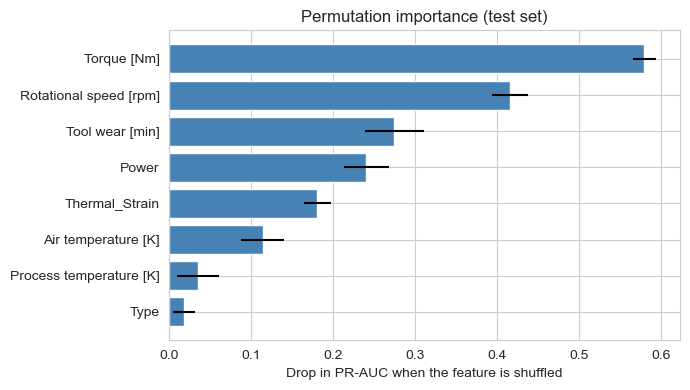

In [19]:
def permutation_importance_ann(model, prep, X, y, n_repeats=10, seed=SEED):
    rng = np.random.default_rng(seed)
    base_score = average_precision_score(y, predict_proba_ann(model, prep.transform(X)))
    out = {}
    for col in X.columns:
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[col] = rng.permutation(X_perm[col].values)
            score = average_precision_score(y, predict_proba_ann(model, prep.transform(X_perm)))
            drops.append(base_score - score)
        out[col] = (np.mean(drops), np.std(drops))
    imp = pd.DataFrame(out, index=["importance", "std"]).T.sort_values("importance")
    return base_score, imp

base_ap, imp_df = permutation_importance_ann(ann, preprocessor, X_test, y_test)
print(f"Test PR-AUC without shuffling: {base_ap:.3f}")

plt.figure(figsize=(7, 4))
plt.barh(imp_df.index, imp_df["importance"], xerr=imp_df["std"], color="steelblue")
plt.xlabel("Drop in PR-AUC when the feature is shuffled")
plt.title("Permutation importance (test set)")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=150)
plt.show()

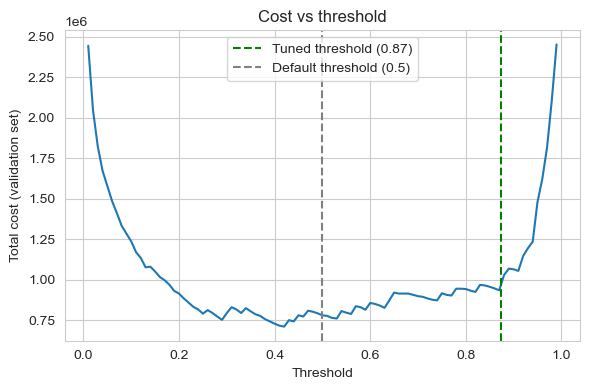

,Missed failures,False alarms,Total cost (assumed)
Setup,,,
No model (never predict failure),68,0,3400000
"ANN, threshold 0.5",10,151,802000
"ANN, tuned threshold 0.87",16,44,888000


In [20]:
COST_MISSED_FAILURE = 50_000   # assumption
COST_FALSE_ALARM = 2_000       # assumption

def total_cost(y_true, preds):
    _, fp, fn, _ = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    return fn * COST_MISSED_FAILURE + fp * COST_FALSE_ALARM

# Cost vs threshold on the validation set
grid = np.linspace(0.01, 0.99, 99)
val_probs = results["ANN"]["val_probs"]
val_costs = [total_cost(y_val, (val_probs >= t).astype(int)) for t in grid]

plt.figure(figsize=(6, 4))
plt.plot(grid, val_costs)
plt.axvline(thr_tuned, ls="--", c="green", label=f"Tuned threshold ({thr_tuned:.2f})")
plt.axvline(0.5, ls="--", c="gray", label="Default threshold (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Total cost (validation set)")
plt.title("Cost vs threshold")
plt.legend()
plt.tight_layout()
plt.savefig("images/cost_vs_threshold.png", dpi=150)
plt.show()

# Test-set comparison
setups = {
    "No model (never predict failure)": np.zeros(len(y_test), dtype=int),
    "ANN, threshold 0.5": (ann_test_probs >= 0.5).astype(int),
    f"ANN, tuned threshold {thr_tuned:.2f}": (ann_test_probs >= thr_tuned).astype(int),
}
cost_rows = []
for label, preds in setups.items():
    _, fp, fn, _ = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()
    cost_rows.append({"Setup": label, "Missed failures": int(fn), "False alarms": int(fp),
                      "Total cost (assumed)": int(total_cost(y_test, preds))})
cost_table = pd.DataFrame(cost_rows).set_index("Setup")
display(cost_table)

In [24]:
os.makedirs("artifacts", exist_ok=True)
torch.save(ann.state_dict(), "artifacts/model.pt")
joblib.dump(preprocessor, "artifacts/preprocessor.pkl")
with open("artifacts/config.json", "w") as f:
    json.dump({"input_dim": int(INPUT_DIM), "threshold": float(thr_tuned), "num_cols": ALL_NUM}, f, indent=2)
print(os.listdir("artifacts"))

['config.json', 'model.pt', 'preprocessor.pkl']


In [25]:
def load_artifacts(folder="artifacts"):
    with open(f"{folder}/config.json") as f:
        cfg = json.load(f)
    prep = joblib.load(f"{folder}/preprocessor.pkl")
    model = Ann(cfg["input_dim"])
    model.load_state_dict(torch.load(f"{folder}/model.pt", map_location="cpu"))
    model.eval()
    return model, prep, cfg

loaded_model, loaded_prep, cfg = load_artifacts()


def predict_failure(air_temp, process_temp, rpm, torque, tool_wear, machine_type):
    """Predict failure for one machine reading. machine_type is 'L', 'M' or 'H'."""
    row = pd.DataFrame([{
        "Type": machine_type,
        "Air temperature [K]": air_temp,
        "Process temperature [K]": process_temp,
        "Rotational speed [rpm]": rpm,
        "Torque [Nm]": torque,
        "Tool wear [min]": tool_wear,
    }])
    row["Thermal_Strain"] = row["Process temperature [K]"] - row["Air temperature [K]"]
    row["Power"] = row["Torque [Nm]"] * row["Rotational speed [rpm]"]

    prob = float(predict_proba_ann(loaded_model, loaded_prep.transform(row))[0])
    return {
        "failure_probability": round(prob, 3),
        "failure_predicted": bool(prob >= cfg["threshold"]),
        "threshold_used": round(cfg["threshold"], 3),
    }

print(predict_failure(air_temp=300.0, process_temp=310.5, rpm=1400, torque=60.0, tool_wear=220, machine_type="L"))
print(predict_failure(air_temp=298.0, process_temp=308.5, rpm=1550, torque=38.0, tool_wear=20, machine_type="M"))

{'failure_probability': 0.999, 'failure_predicted': True, 'threshold_used': 0.874}
{'failure_probability': 0.001, 'failure_predicted': False, 'threshold_used': 0.874}


In [26]:
def to_markdown(table):
    t = table.reset_index()
    header = "| " + " | ".join(str(c) for c in t.columns) + " |"
    sep = "|" + "---|" * len(t.columns)
    body = ["| " + " | ".join(str(v) for v in row) + " |" for row in t.values]
    return "\n".join([header, sep] + body)

print("### Model comparison (test set)\n" + to_markdown(comparison) + "\n")
print("### ANN at two thresholds (test set)\n" + to_markdown(op_table) + "\n")
print("### Ablation study (3 seeds)\n" + to_markdown(ablation_table) + "\n")
print("### 5-fold cross-validation\n" + to_markdown(cv_summary) + "\n")
print("### Business cost (assumed costs)\n" + to_markdown(cost_table))

### Model comparison (test set)
| Model | Val PR-AUC | Test PR-AUC | Test ROC-AUC |
|---|---|---|---|
| Logistic Regression | 0.451 | 0.471 | 0.93 |
| Random Forest | 0.832 | 0.853 | 0.958 |
| ANN | 0.708 | 0.701 | 0.97 |

### ANN at two thresholds (test set)
| Setup | Precision | Recall | F1 | Failures caught | Missed failures | False alarms |
|---|---|---|---|---|---|---|
| ANN, threshold Default 0.5 | 0.278 | 0.853 | 0.419 | 58 | 10 | 151 |
| ANN, threshold Tuned 0.87 | 0.542 | 0.765 | 0.634 | 52 | 16 | 44 |

### Ablation study (3 seeds)
| Setup | Test PR-AUC (mean) | Test PR-AUC (std) | Test ROC-AUC (mean) |
|---|---|---|---|
| With engineered features | 0.756 | 0.018 | 0.976 |
| Without engineered features | 0.713 | 0.041 | 0.972 |

### 5-fold cross-validation
| Model | PR-AUC (mean) | PR-AUC (std) | ROC-AUC (mean) | ROC-AUC (std) |
|---|---|---|---|---|
| ANN | 0.709 | 0.011 | 0.964 | 0.01 |
| Logistic Regression | 0.484 | 0.028 | 0.92 | 0.014 |
| Random Forest | 0.867 | 0.035 | 